# Extra Practice

This is meant to help you practise the same core skills you developed in the previous exercises. Completing these exercises are **optional** and only meant to provide a little extra practice if you want. 


### Set up Python Libraries

As usual you will need to run this code block to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Import the data

We need some data to work with. We will import a dataset that looks at student achievement in secondary education of two schools The data attributes include student grades, demographic, social and school related features) and it was collected by using school reports and questionnaires.

Here's a list and description of the variables:

* `school`: student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)
* `sex`: student's sex ('F' - female or 'M' - male)
* `age`: student's age (integer 15-22)
* `Mjob`: mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')
* `Fjob`: father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')
* `traveltime`: home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)
* `studytime`: weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
* `nursery`: attended nursery school (binary: yes or no)	
* `femrel`: quality of family relationships (numeric: from 1 - very bad to 5 - excellent)	
* `freetime`: free time after school (numeric: from 1 - very low to 5 - very high)	
* `absences`: number of school absences (numeric: from 0 to 93)	
* `G1`: first term grade (numeric: from 0 to 20)	
* `G2`: mid term grade (numeric: from 0 to 20)	
* `G3`: final term grade (numeric: from 0 to 20, output target)

In [2]:
student = pd.read_csv("https://raw.githubusercontent.com/SageBoettcher/StatsCourseBook_2026/main/data/student.csv")
display(student)

,school,sex,age,Mjob,Fjob,traveltime,studytime,nursery,famrel,freetime,absences,G1,G2,G3
0,GP,F,18,at_home,teacher,2,2,yes,4,3,6,5,6,6
1,GP,F,17,at_home,other,1,2,no,5,3,4,5,5,6
2,GP,F,15,at_home,other,1,2,yes,4,3,10,7,8,10
3,GP,F,15,health,services,1,3,yes,3,2,2,15,14,15
4,GP,F,16,other,other,1,2,yes,4,3,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,services,services,1,2,yes,5,5,11,9,9,9
391,MS,M,17,services,services,2,1,no,2,4,3,14,16,16
392,MS,M,21,other,other,1,1,no,5,5,3,10,8,7
393,MS,M,18,services,other,3,1,no,4,4,0,11,12,10


## Part 1: Paired Data

Let's start by considering the paired nature of the data. Here we have *repeated measures* design, where each student as 3 exam scores G1: first term grade G2: mid-term grade and G3: final grade. 

**In this case we might want to ask whether students performance differed in the final exam compared to their performance in the first term.**

#### Things you need to decide:

* what is our null hypothesis
* what is our alternative hypothesis?

Is it a paired or unpaired test?
* therefore which `permutation_type` is needed, `samples`, `pairings` or `independent`?
* are we testing for the mean difference (within pairs) `mean(x-y)`, or the difference of means `mean(x)-mean(y)`
* what actually are `x` and `y` in this case?
        
Is it a one- or two-tailed test?
* therefore which `alternative` hypothesis type is needed, `two-sided`, `greater` or `less`?

What $\alpha$ value will you use?
* what value must $p$ be smaller than, to reject the null hypothesis?
* this is the experimenter's choice but usually 0.05 is used (sometimes 0.001 or 0.001)

*Your answers here*

After you've made some decisions about the type of tests you'd like to run, you will want to start by plotting your data. 

**What plot makese sense for this dataset?**

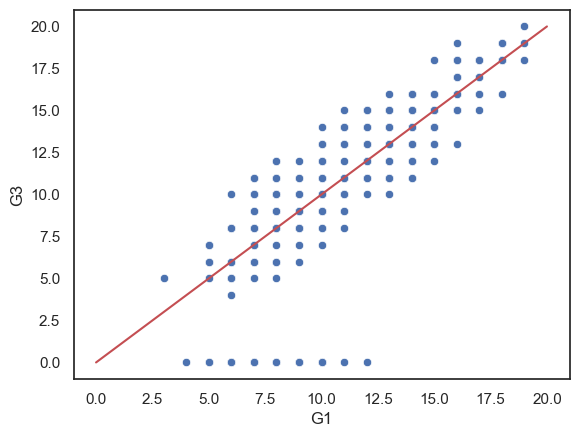

In [3]:
#Your Code Here

sns.scatterplot(data=student, x ='G1', y='G3')
plt.plot([0,20],[0,20], 'r')
plt.show()

Maybe you already have a sense of wether or not there might be a difference in the scores. 

**What is the Test statistic and descriptive statistics**

-0.4936708860759494


<Axes: ylabel='G3_G1_diff'>

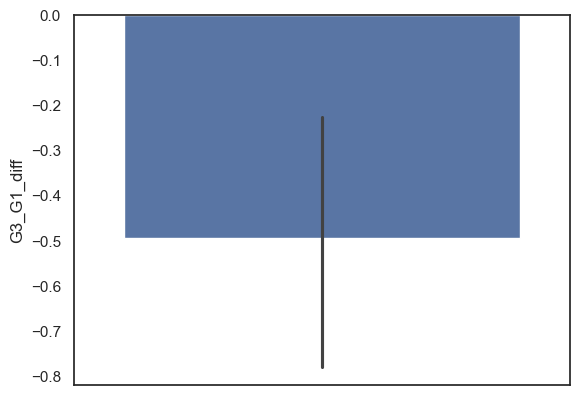

In [4]:
#Your Code Here

student['G3_G1_diff'] = student.G3-student.G1 # create a new column for the within-student difference
print(student.G3_G1_diff.mean())

sns.barplot(data = student, y = 'G3_G1_diff')

In [5]:
student.agg({'G3':['count','mean', 'std'],
        'G1':['count','mean', 'std'],
        'G3_G1_diff':['count','mean', 'std']})

,G3,G1,G3_G1_diff
count,395.000000,395.000000,395.000000
mean,10.415190,10.908861,-0.493671
std,4.581443,3.319195,2.762482


**Now perform your permutation test**

PermutationTestResult(statistic=np.float64(-0.4936708860759494), pvalue=np.float64(0.00039996000399960006), null_distribution=array([ 0.10886076,  0.04303797,  0.12911392, ...,  0.13924051,
        0.10886076, -0.01265823], shape=(10000,)))


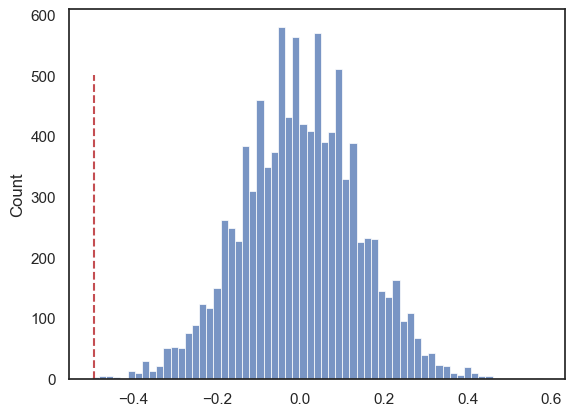

In [6]:
#Your code here
def mDiff(x, y):
    return np.mean(x-y)

results = stats.permutation_test((student.G3, student.G1), mDiff, permutation_type='samples', alternative='two-sided', n_resamples=10000)

print(results)


sns.histplot(results.null_distribution)
plt.plot([results.statistic,results.statistic],[0,500], 'r--')
plt.show()

**Report conclusion**


*Your answer here*

**Write up**


*Your answer here*

## Part 2: Unpaired Data

We might want to next consider whether overall performance differs across different groups. 

We may want to add an additional variable to our dataset which accounts for each students' overall performance (i.e., an average of the performance in each of the tests)

In [7]:
student['avgPerf'] = (student.G1 + student.G2 + student.G3)/3
student

,school,sex,age,Mjob,Fjob,traveltime,studytime,nursery,famrel,freetime,absences,G1,G2,G3,G3_G1_diff,avgPerf
0,GP,F,18,at_home,teacher,2,2,yes,4,3,6,5,6,6,1,5.666667
1,GP,F,17,at_home,other,1,2,no,5,3,4,5,5,6,1,5.333333
2,GP,F,15,at_home,other,1,2,yes,4,3,10,7,8,10,3,8.333333
3,GP,F,15,health,services,1,3,yes,3,2,2,15,14,15,0,14.666667
4,GP,F,16,other,other,1,2,yes,4,3,4,6,10,10,4,8.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,services,services,1,2,yes,5,5,11,9,9,9,0,9.000000
391,MS,M,17,services,services,2,1,no,2,4,3,14,16,16,2,15.333333
392,MS,M,21,other,other,1,1,no,5,5,3,10,8,7,-3,8.333333
393,MS,M,18,services,other,3,1,no,4,4,0,11,12,10,-1,11.000000


Here there are several groups you might be interested in testing their average performance:

* Does performanc differ by school (GP & MS)?
* Does performance differ by sex?
* Does performance differ by whether the sudent attended nursery?

Decide which factor you would like to test and determine your hypotheses:

#### Things you need to decide:

* what is our null hypothesis
* what is our alternative hypothesis?

Is it a paired or unpaired test?
* therefore which `permutation_type` is needed, `samples`, `pairings` or `independent`?
* are we testing for the mean difference (within pairs) `mean(x-y)`, or the difference of means `mean(x)-mean(y)`
* what actually are `x` and `y` in this case?
        
Is it a one- or two-tailed test?
* therefore which `alternative` hypothesis type is needed, `two-sided`, `greater` or `less`?

What $\alpha$ value will you use?
* what value must $p$ be smaller than, to reject the null hypothesis?
* this is the experimenter's choice but usually 0.05 is used (sometimes 0.001 or 0.001)

After you've made some decisions about the type of tests you'd like to run, you will want to start by plotting your data. 

**What plot makese sense for this dataset?**

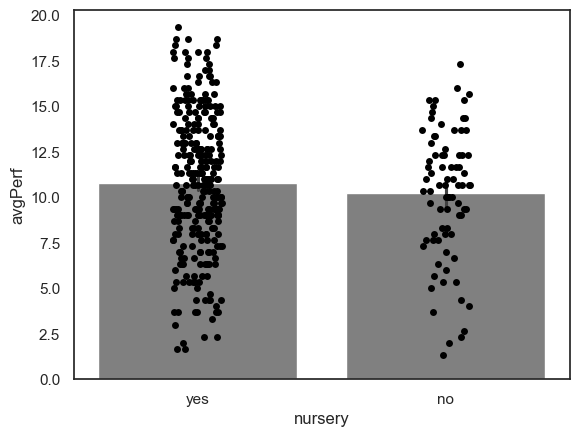

In [8]:
#Your code here

sns.barplot(data = student, x = 'nursery', y = 'avgPerf', color = 'gray')
sns.stripplot(data = student, x = 'nursery', y = 'avgPerf', color = 'black')

plt.show()

Maybe you already have a sense of wether or not there might be a difference in the scores. 

**What is the Test statistic and descriptive statistics**

In [9]:
#Your code here
# find the means, sd and n
student.groupby('nursery').agg({ 'avgPerf':['count','mean', 'std']})

avgPerf                     
          count       mean       std
nursery                             
no           81  10.205761  3.565096
yes         314  10.801486  3.725762

**Now perform your permutation test**

PermutationTestResult(statistic=np.float64(-0.4936708860759494), pvalue=np.float64(0.00039996000399960006), null_distribution=array([ 0.10886076,  0.04303797,  0.12911392, ...,  0.13924051,
        0.10886076, -0.01265823], shape=(10000,)))


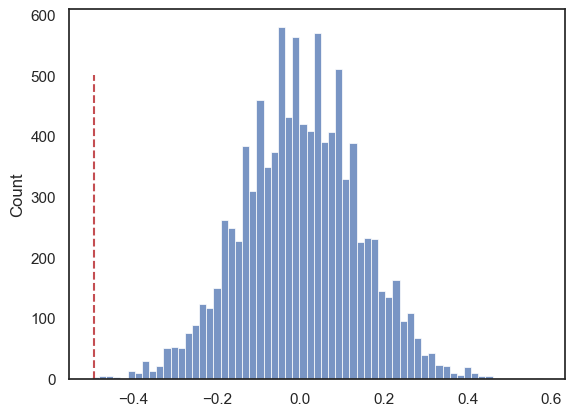

In [10]:
#Your code here
def dMeans(x, y):
    return np.mean(x)-np.mean(y)

# run the permutation test
stats.permutation_test((student.query('nursery == "no"').avgPerf, 
                        student.query('nursery == "yes"').avgPerf), 
                        dMeans, alternative='two-sided', permutation_type='independent', n_resamples=10000)

print(results)

sns.histplot(results.null_distribution)
plt.plot([results.statistic,results.statistic],[0,500], 'r--')
plt.show()

**Report conclusion**


*Your answer here*

**Write up**


*Your answer here*

## Part 3: Correlation

Finally, you might be interested if any of the variables in our dataset are related. Here you could consider how any of our continuous variables (`traveltime`, `familyrel`, `freetime`, `absences`, `G1`, `G2`, `G3`, `avgPerf`, etc.) might relate to one another.

Decide which relationship you'd like to test:

#### Things you need to decide:

* what is our null hypothesis
* what is our alternative hypothesis?

Is it a paired or unpaired test?
* therefore which `permutation_type` is needed, `samples`, `pairings` or `independent`?
* are we testing for the mean difference (within pairs) `mean(x-y)`, or the difference of means `mean(x)-mean(y)`
* what actually are `x` and `y` in this case?
        
Is it a one- or two-tailed test?
* therefore which `alternative` hypothesis type is needed, `two-sided`, `greater` or `less`?

What $\alpha$ value will you use?
* what value must $p$ be smaller than, to reject the null hypothesis?
* this is the experimenter's choice but usually 0.05 is used (sometimes 0.001 or 0.001)

After you've made some decisions about the type of tests you'd like to run, you will want to start by plotting your data. 

**What plot makese sense for this dataset?**

<Axes: xlabel='studytime', ylabel='avgPerf'>

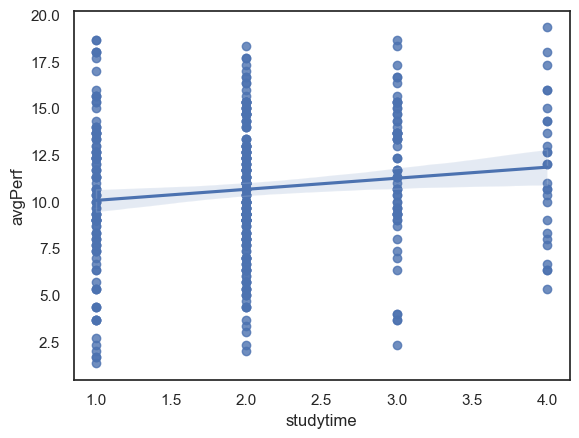

In [11]:
#Your code here

sns.regplot(data = student, x = 'studytime', y = 'avgPerf')

Maybe you already have a sense of wether or not there might be a relationship in the scores. 

**What is the Test statistic and descriptive statistics**

In [12]:
student.studytime.corr(student.avgPerf)

np.float64(0.13456471886640692)

**Now perform your permutation test**

PermutationTestResult(statistic=np.float64(0.13456471886640692), pvalue=np.float64(0.007399260073992601), null_distribution=array([-0.06395483,  0.00803578, -0.0091438 , ..., -0.10976703,
        0.0762087 , -0.01323418], shape=(10000,)))


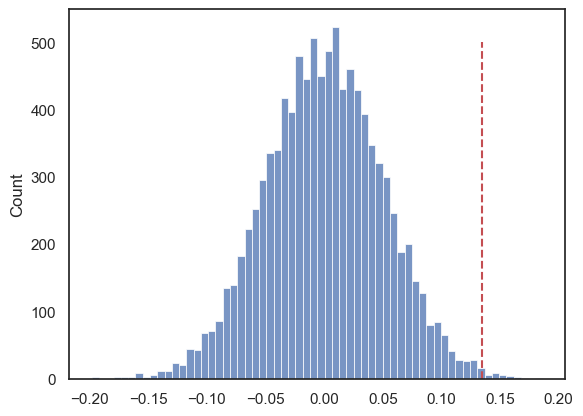

In [13]:
#Your code
# define a function that gives the correlation for two series x and y
# note that np.corrcoef returns a 2x2 matrix so we need to get just the relevant element
def mycorr(x,y):
    c = np.corrcoef(x,y)
    return c[0,1]

# run the permutation test
results = stats.permutation_test((student.studytime,student.avgPerf), mycorr, alternative='two-sided', permutation_type='pairings', n_resamples=10000)
print(results)

sns.histplot(results.null_distribution)
plt.plot([results.statistic,results.statistic],[0,500], 'r--')
plt.show()

**Report conclusion**


*Your answer here*

**Write up**


*Your answer here*